# 05.5 — Tokenization Quality Check

Sanity checks on the preprocessed dataset **before** training.

### Checks performed
| # | Check | What it catches |
|---|-------|------------------|
| 1 | Binary file integrity | Corrupt / truncated `.bin` files |
| 2 | Meta.json consistency | Mismatched shapes / counts |
| 3 | Token distribution | Degenerate vocab, missing categories |
| 4 | Structural grammar | Broken CHORD_START/END pairing, BAR placement |
| 5 | EigenSpace ranges | Out-of-range α,β,γ,δ values |
| 6 | Tetrahedron constraint | α ≤ β ≤ γ violations |
| 7 | Padding analysis | Excessive padding, efficiency |
| 8 | Round-trip decode | Encode → decode → re-encode consistency |
| 9 | Per-song JSON spot check | Random sample structural validation |
| 10 | Visualizations | Distributions, EigenSpace scatter, sequence lengths |

In [1]:
import sys, json, importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# ── Path setup ────────────────────────────────────────────────────────────
SRC_DIR  = Path('.').resolve()
ROOT_DIR = SRC_DIR.parent
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ── Directories ──────────────────────────────────────────────────────────
TOKENIZED_DIR  = ROOT_DIR / 'dataset' / 'tokenized'
PREPROCESSED   = ROOT_DIR / 'dataset' / 'preprocessed'
SONGS_DIR      = PREPROCESSED / 'songs'
MIDI_DIR       = ROOT_DIR / 'dataset' / 'midi_files' / '53_tet_mpe'

# ── Load meta ────────────────────────────────────────────────────────────
with open(TOKENIZED_DIR / 'meta.json') as f:
    meta = json.load(f)

with open(TOKENIZED_DIR / 'vocab.json') as f:
    vocab_data = json.load(f)

token_to_id = vocab_data['token_to_id']
id_to_token = {v: k for k, v in token_to_id.items()}

VOCAB_SIZE = meta['vocab_size']
BLOCK_SIZE = meta['block_size']
SEQ_LEN    = meta['seq_len']        # block_size + 1 = 4097
N_TRAIN    = meta['n_train_seqs']
N_VAL      = meta['n_val_seqs']
PAD_ID     = token_to_id['<pad>']

print(f"Vocab size:    {VOCAB_SIZE:,}")
print(f"Block size:    {BLOCK_SIZE}")
print(f"Seq length:    {SEQ_LEN}")
print(f"Train seqs:    {N_TRAIN:,}")
print(f"Val seqs:      {N_VAL:,}")
print(f"Train songs:   {meta['n_train_songs']:,}")
print(f"Val songs:     {meta['n_val_songs']:,}")
print(f"Total tokens:  {meta['total_tokens']:,}")
print(f"PAD ID:        {PAD_ID}")

Vocab size:    2,623
Block size:    4096
Seq length:    4097
Train seqs:    659,773
Val seqs:      13,459
Train songs:   659,439
Val songs:     13,457
Total tokens:  893,270,240
PAD ID:        0


## 1 — Binary File Integrity

Verify that the `.bin` files can be memory-mapped with the expected shapes and dtypes.

In [2]:
def load_mmap(name, dtype, shape):
    """Memory-map a binary file and verify shape."""
    path = TOKENIZED_DIR / name
    arr = np.memmap(path, dtype=dtype, mode='r').reshape(shape)
    size_mb = path.stat().st_size / (1024**2)
    return arr, size_mb

# Load all four binary files
train_tok, train_tok_mb = load_mmap('train_tokens.bin', np.uint16, (N_TRAIN, SEQ_LEN))
train_eig, train_eig_mb = load_mmap('train_eigen.bin',  np.float16, (N_TRAIN, SEQ_LEN, 4))
val_tok,   val_tok_mb   = load_mmap('val_tokens.bin',   np.uint16, (N_VAL, SEQ_LEN))
val_eig,   val_eig_mb   = load_mmap('val_eigen.bin',    np.float16, (N_VAL, SEQ_LEN, 4))

total_mb = train_tok_mb + train_eig_mb + val_tok_mb + val_eig_mb

print("Binary file integrity: OK")
print(f"  train_tokens.bin : {train_tok.shape}  {train_tok.dtype}  ({train_tok_mb:,.1f} MB)")
print(f"  train_eigen.bin  : {train_eig.shape}  {train_eig.dtype}  ({train_eig_mb:,.1f} MB)")
print(f"  val_tokens.bin   : {val_tok.shape}    {val_tok.dtype}    ({val_tok_mb:,.1f} MB)")
print(f"  val_eigen.bin    : {val_eig.shape}    {val_eig.dtype}    ({val_eig_mb:,.1f} MB)")
print(f"  Total on disk:   {total_mb:,.1f} MB ({total_mb/1024:.2f} GB)")

Binary file integrity: OK
  train_tokens.bin : (659773, 4097)  uint16  (5,155.7 MB)
  train_eigen.bin  : (659773, 4097, 4)  float16  (20,622.9 MB)
  val_tokens.bin   : (13459, 4097)    uint16    (105.2 MB)
  val_eigen.bin    : (13459, 4097, 4)    float16    (420.7 MB)
  Total on disk:   26,304.5 MB (25.69 GB)


## 2 — Meta.json Consistency

Cross-check meta.json counts against actual binary array shapes.

In [3]:
checks = []

def check(name, condition, detail=""):
    status = "PASS" if condition else "FAIL"
    checks.append((name, status, detail))
    icon = "\u2705" if condition else "\u274c"
    print(f"  {icon} {name}: {status}  {detail}")

print("Meta.json consistency checks:")
check("vocab_size matches vocab.json",
      meta['vocab_size'] == len(token_to_id),
      f"meta={meta['vocab_size']}, vocab={len(token_to_id)}")

check("train seq count matches binary",
      meta['n_train_seqs'] == train_tok.shape[0],
      f"meta={meta['n_train_seqs']}, bin={train_tok.shape[0]}")

check("val seq count matches binary",
      meta['n_val_seqs'] == val_tok.shape[0],
      f"meta={meta['n_val_seqs']}, bin={val_tok.shape[0]}")

check("seq_len == block_size + 1",
      meta['seq_len'] == meta['block_size'] + 1,
      f"seq_len={meta['seq_len']}, block_size={meta['block_size']}")

check("token/eigen seq shapes match",
      train_tok.shape[:2] == train_eig.shape[:2] and val_tok.shape[:2] == val_eig.shape[:2],
      f"train: tok={train_tok.shape[:2]}, eig={train_eig.shape[:2]}")

check("eigenspace has 4 dims",
      train_eig.shape[2] == 4 and val_eig.shape[2] == 4)

# Real token count check
# (Sampling a subset for speed — full count on 943k seqs would be slow)
SAMPLE_N = min(5000, N_TRAIN)
rng = np.random.default_rng(42)
sample_idx = rng.choice(N_TRAIN, SAMPLE_N, replace=False)
sample_tok = train_tok[sample_idx]
real_per_seq = np.sum(sample_tok != PAD_ID, axis=1)
est_total_real = int(real_per_seq.mean() * N_TRAIN)

check("total real tokens plausible (est from sample)",
      abs(est_total_real - meta['n_train_tokens']) / meta['n_train_tokens'] < 0.05,
      f"estimated={est_total_real:,}, meta={meta['n_train_tokens']:,}")

n_pass = sum(1 for _, s, _ in checks if s == 'PASS')
print(f"\n  {n_pass}/{len(checks)} checks passed")

Meta.json consistency checks:
  ✅ vocab_size matches vocab.json: PASS  meta=2623, vocab=2623
  ✅ train seq count matches binary: PASS  meta=659773, bin=659773
  ✅ val seq count matches binary: PASS  meta=13459, bin=13459
  ✅ seq_len == block_size + 1: PASS  seq_len=4097, block_size=4096
  ✅ token/eigen seq shapes match: PASS  train: tok=(659773, 4097), eig=(659773, 4097)
  ✅ eigenspace has 4 dims: PASS  
  ✅ total real tokens plausible (est from sample): PASS  estimated=866,814,517, meta=875,494,166

  7/7 checks passed


## 3 — Token ID Range & Distribution

Verify all token IDs are within `[0, vocab_size)` and check the distribution across categories.

In [4]:
# Sample a batch of sequences for fast analysis
SAMPLE_SEQS = min(10000, N_TRAIN)
idx = rng.choice(N_TRAIN, SAMPLE_SEQS, replace=False)
sample_flat = train_tok[idx].ravel()

# Range check
min_id, max_id = int(sample_flat.min()), int(sample_flat.max())
print(f"Token ID range: [{min_id}, {max_id}]  (vocab_size={VOCAB_SIZE})")
assert max_id < VOCAB_SIZE, f"Token ID {max_id} >= vocab_size {VOCAB_SIZE}!"
print("  Range check: PASS")

# Count by category
counts = Counter(sample_flat.tolist())

categories = {
    'PAD':      [PAD_ID],
    'SPECIAL':  [token_to_id.get(t, -1) for t in ['<start>', '<end>', '<sep>'] if t in token_to_id],
    'STRUCT':   [token_to_id.get(t, -1) for t in ['CHORD_START', 'CHORD_END', 'BAR', 'REST'] if t in token_to_id],
    'DUR':      [v for k, v in token_to_id.items() if k.startswith('DUR_')],
    'ROOT':     [v for k, v in token_to_id.items() if k.startswith('ROOT_')],
    'PV':       [v for k, v in token_to_id.items() if k.startswith('PV_')],
}

print(f"\nToken distribution ({SAMPLE_SEQS:,} sampled sequences):")
total_sampled = len(sample_flat)
for cat_name, cat_ids in categories.items():
    cat_count = sum(counts.get(tid, 0) for tid in cat_ids)
    pct = cat_count / total_sampled * 100
    used = sum(1 for tid in cat_ids if counts.get(tid, 0) > 0)
    print(f"  {cat_name:<10s} {cat_count:>12,}  ({pct:5.1f}%)  {used}/{len(cat_ids)} unique")

# Unused token IDs
all_used = set(counts.keys())
unused = set(range(VOCAB_SIZE)) - all_used
print(f"\nVocab coverage: {len(all_used):,}/{VOCAB_SIZE:,} used ({len(all_used)/VOCAB_SIZE*100:.1f}%)")
print(f"Unused tokens:  {len(unused):,}")

Token ID range: [0, 2594]  (vocab_size=2623)
  Range check: PASS

Token distribution (10,000 sampled sequences):
  PAD          27,657,413  ( 67.5%)  1/1 unique
  SPECIAL          19,990  (  0.0%)  2/3 unique
  STRUCT        4,277,975  ( 10.4%)  3/4 unique
  DUR           1,262,632  (  3.1%)  9/10 unique
  ROOT          1,262,632  (  3.1%)  53/53 unique
  PV            6,489,358  ( 15.8%)  876/2552 unique

Vocab coverage: 944/2,623 used (36.0%)
Unused tokens:  1,679


In [5]:
# Top 30 most frequent tokens (excluding PAD)
non_pad = {k: v for k, v in counts.items() if k != PAD_ID}
top30 = sorted(non_pad.items(), key=lambda x: -x[1])[:30]

print("Top 30 tokens (excl. PAD):")
for rank, (tid, cnt) in enumerate(top30, 1):
    tok_str = id_to_token.get(tid, f'UNK_{tid}')
    pct = cnt / sum(non_pad.values()) * 100
    print(f"  {rank:2d}. [{tid:4d}] {tok_str:<25s} {cnt:>10,}  ({pct:.2f}%)")

Top 30 tokens (excl. PAD):
   1. [   6] BAR                        1,752,715  (13.17%)
   2. [   4] CHORD_START                1,262,632  (9.48%)
   3. [   5] CHORD_END                  1,262,628  (9.48%)
   4. [  13] DUR_4.0                      560,689  (4.21%)
   5. [  15] DUR_8.0                      511,688  (3.84%)
   6. [1347] PV_265_5                      94,645  (0.71%)
   7. [1275] PV_256_5                      91,013  (0.68%)
   8. [1419] PV_274_5                      90,330  (0.68%)
   9. [1379] PV_269_5                      89,849  (0.67%)
  10. [  11] DUR_2.0                       88,790  (0.67%)
  11. [  14] DUR_6.0                       85,756  (0.64%)
  12. [1315] PV_261_5                      84,874  (0.64%)
  13. [1451] PV_278_5                      82,233  (0.62%)
  14. [1595] PV_296_5                      74,349  (0.56%)
  15. [1243] PV_252_5                      74,155  (0.56%)
  16. [1491] PV_283_5                      73,889  (0.56%)
  17. [  36] ROOT_18        

## 4 — Structural Grammar Checks

Verify token sequences follow the expected grammar:
- Every sequence starts with `<start>` (or `<pad>` if entirely padding)
- `CHORD_START` / `CHORD_END` are properly paired
- Inside each chord: `DUR`, `ROOT`, then `PV` tokens
- `BAR` tokens appear between chords

In [6]:
# IDs for structural tokens
START_ID  = token_to_id['<start>']
END_ID    = token_to_id['<end>']
CS_ID     = token_to_id['CHORD_START']
CE_ID     = token_to_id['CHORD_END']
BAR_ID    = token_to_id['BAR']

DUR_IDS   = set(v for k, v in token_to_id.items() if k.startswith('DUR_'))
ROOT_IDS  = set(v for k, v in token_to_id.items() if k.startswith('ROOT_'))
PV_IDS    = set(v for k, v in token_to_id.items() if k.startswith('PV_'))

# Check a random sample of sequences
N_CHECK = min(5000, N_TRAIN)
check_idx = rng.choice(N_TRAIN, N_CHECK, replace=False)

grammar_issues = Counter()
n_good = 0

for i in check_idx:
    seq = train_tok[i]
    # Strip padding
    real = seq[seq != PAD_ID]
    if len(real) == 0:
        grammar_issues['empty_sequence'] += 1
        continue

    issues = []

    # Check start token
    if real[0] != START_ID:
        issues.append('missing_start')

    # Check end token
    if real[-1] != END_ID:
        issues.append('missing_end')

    # Check CHORD_START/END pairing
    cs_count = np.sum(real == CS_ID)
    ce_count = np.sum(real == CE_ID)
    if cs_count != ce_count:
        issues.append(f'chord_pair_mismatch(CS={cs_count},CE={ce_count})')

    # Walk through and check chord internals
    in_chord = False
    chord_has_dur = False
    chord_has_root = False
    chord_has_pv = False

    for t in real:
        tid = int(t)
        if tid == CS_ID:
            if in_chord:
                issues.append('nested_chord_start')
            in_chord = True
            chord_has_dur = False
            chord_has_root = False
            chord_has_pv = False
        elif tid == CE_ID:
            if not in_chord:
                issues.append('orphan_chord_end')
            else:
                if not chord_has_dur:
                    issues.append('chord_missing_dur')
                if not chord_has_root:
                    issues.append('chord_missing_root')
                if not chord_has_pv:
                    issues.append('chord_missing_pv')
            in_chord = False
        elif in_chord:
            if tid in DUR_IDS:
                chord_has_dur = True
            elif tid in ROOT_IDS:
                chord_has_root = True
            elif tid in PV_IDS:
                chord_has_pv = True

    if in_chord:
        issues.append('unclosed_chord')

    if issues:
        for iss in issues:
            grammar_issues[iss] += 1
    else:
        n_good += 1

print(f"Grammar check ({N_CHECK:,} sequences):")
print(f"  Valid:  {n_good:,} ({n_good/N_CHECK*100:.1f}%)")
if grammar_issues:
    print(f"  Issues found:")
    for issue, cnt in grammar_issues.most_common():
        print(f"    {issue}: {cnt:,} ({cnt/N_CHECK*100:.2f}%)")
else:
    print("  No grammar issues found!")

Grammar check (5,000 sequences):
  Valid:  4,998 (100.0%)
  Issues found:
    missing_end: 1 (0.02%)
    chord_pair_mismatch(CS=422,CE=421): 1 (0.02%)
    unclosed_chord: 1 (0.02%)
    missing_start: 1 (0.02%)
    chord_pair_mismatch(CS=49,CE=50): 1 (0.02%)
    orphan_chord_end: 1 (0.02%)


## 5 — EigenSpace Range Checks

Ranges derived from the 53-TET canonical intervals in `eigenspace.py`:

| Axis | Source | Canonical steps | Ratio range |
|------|--------|-----------------|-------------|
| α (3rd) | `CANONICAL_THIRDS` [11…22] | 11 steps = `2^(11/53)` … 22 steps = `2^(22/53)` | ≈ [1.154, 1.333] or 1.0 (no 3rd) |
| β (5th) | `CANONICAL_FIFTHS` [26, 31, 35] | 26 … 35 steps | ≈ [1.367, 1.558], default=31→1.498 |
| γ (7th) | `CANONICAL_SEVENTHS` [42…51] | 42 … 51 steps | ≈ [1.722, 1.974] or γ=β (triad) |
| δ (root) | `2^(root_pc/53)`, pc ∈ [0, 52] | 0 … 52 steps | [1.0, 1.987] |

Non-chord token embedding: `DEFAULT_EIGEN` from `pack_data.py`.

In [7]:
from eigenspace import (
    CANONICAL_THIRDS, CANONICAL_FIFTHS, CANONICAL_SEVENTHS,
    get_53tet_ratio, DEFAULT_ALPHA, DEFAULT_BETA, DEFAULT_GAMMA, DEFAULT_DELTA,
    TET_53,
)
from pack_data import DEFAULT_EIGEN

# ── Build the set of ALL reachable eigenspace values per axis ─────────────
# α: chord thirds snapped to canonical, or DEFAULT_ALPHA (no third / structural)
alpha_chord = sorted(set(get_53tet_ratio(s) for s in CANONICAL_THIRDS))
# β: always assigned (default=31 if no fifth detected), so only canonical values
beta_chord  = sorted(set(get_53tet_ratio(s) for s in CANONICAL_FIFTHS))
# γ: either a canonical seventh, or γ=β for triads
gamma_chord = sorted(set(get_53tet_ratio(s) for s in CANONICAL_SEVENTHS))
gamma_triad = beta_chord  # triads: γ collapses to β
# δ: 2^(root_pc/53) for root_pc in [0, 52]
delta_all   = sorted(set(get_53tet_ratio(pc) for pc in range(TET_53)))

# Chord-token valid ranges (tokens inside CHORD_START…CHORD_END)
CHORD_RANGES = {
    'α': (min(alpha_chord + [DEFAULT_ALPHA]), max(alpha_chord + [DEFAULT_ALPHA])),
    'β': (min(beta_chord),  max(beta_chord)),
    'γ': (min(gamma_triad + gamma_chord), max(gamma_triad + gamma_chord)),
    'δ': (min(delta_all),   max(delta_all)),
}

# ── Classify tokens into chord vs structural ─────────────────────────────
eig_sample = train_eig[idx].reshape(-1, 4).astype(np.float32)
tok_sample = train_tok[idx].ravel()

# Three populations:
pad_mask       = tok_sample == PAD_ID
chord_tok_ids  = DUR_IDS | ROOT_IDS | PV_IDS | {CS_ID, CE_ID}
chord_mask     = np.isin(tok_sample, list(chord_tok_ids)) & ~pad_mask
structural_mask = ~pad_mask & ~chord_mask  # <start>, <end>, BAR, REST, etc.

eig_chord      = eig_sample[chord_mask]
eig_structural = eig_sample[structural_mask]
eig_pad        = eig_sample[pad_mask]

axis_labels = ['α (3rd)', 'β (5th)', 'γ (7th)', 'δ (root)']
axis_keys   = ['α', 'β', 'γ', 'δ']

# ── 5a: Chord token ranges ───────────────────────────────────────────────
print(f"Chord-token EigenSpace ({eig_chord.shape[0]:,} tokens):")
print(f"{'Axis':<12s} {'Mean':>8s} {'Std':>8s} {'Min':>8s} {'Max':>8s}   {'Valid':>14s} {'OK':>5s}")
print("─" * 72)

for i, (label, key) in enumerate(zip(axis_labels, axis_keys)):
    col = eig_chord[:, i]
    mn, mx = col.min(), col.max()
    lo, hi = CHORD_RANGES[key]
    tol = 0.01  # float16 rounding
    ok = (mn >= lo - tol) and (mx <= hi + tol)
    print(f"{label:<12s} {col.mean():8.4f} {col.std():8.4f} {mn:8.4f} {mx:8.4f}   [{lo:.3f},{hi:.3f}] {'PASS' if ok else 'FAIL':>5s}")

# ── 5b: Structural tokens should all be DEFAULT_EIGEN ─────────────────────
print(f"\nStructural-token EigenSpace ({eig_structural.shape[0]:,} tokens):")
struct_mean = eig_structural.mean(axis=0)
struct_std  = eig_structural.std(axis=0)
struct_ok   = np.allclose(struct_mean, DEFAULT_EIGEN, atol=0.01) and np.all(struct_std < 0.01)
print(f"  Mean:     {struct_mean}  (expect {DEFAULT_EIGEN.tolist()})")
print(f"  Std:      {struct_std}  (expect ~0)")
print(f"  Check:    {'PASS' if struct_ok else 'FAIL'}")

# ── 5c: Padding should all be DEFAULT_EIGEN ───────────────────────────────
print(f"\nPadding EigenSpace ({eig_pad.shape[0]:,} positions):")
pad_mean = eig_pad.mean(axis=0)
pad_std  = eig_pad.std(axis=0)
pad_ok   = np.allclose(pad_mean, DEFAULT_EIGEN, atol=0.01) and np.all(pad_std < 0.01)
print(f"  Mean:     {pad_mean}  (expect {DEFAULT_EIGEN.tolist()})")
print(f"  Std:      {pad_std}  (expect ~0)")
print(f"  Check:    {'PASS' if pad_ok else 'FAIL'}")
if not pad_ok:
    # Diagnose: what fraction of padding has DEFAULT_EIGEN vs something else
    is_default = np.all(np.abs(eig_pad - DEFAULT_EIGEN) < 0.01, axis=1)
    is_zero    = np.all(np.abs(eig_pad) < 0.01, axis=1)
    n_def  = is_default.sum()
    n_zero = is_zero.sum()
    n_other = eig_pad.shape[0] - n_def - n_zero
    print(f"  Diagnosis:")
    print(f"    DEFAULT_EIGEN: {n_def:,} ({n_def/eig_pad.shape[0]*100:.1f}%)")
    print(f"    All zeros:     {n_zero:,} ({n_zero/eig_pad.shape[0]*100:.1f}%)")
    print(f"    Other:         {n_other:,} ({n_other/eig_pad.shape[0]*100:.1f}%)")
    if n_other > 0:
        other_mask = ~is_default & ~is_zero
        print(f"    Sample 'other' values: {eig_pad[other_mask][:5]}")

Chord-token EigenSpace (11,539,882 tokens):
Axis             Mean      Std      Min      Max            Valid    OK
────────────────────────────────────────────────────────────────────────
α (3rd)        1.2325   0.0512   1.0000   1.3330   [1.000,1.333]  PASS
β (5th)        1.4944   0.0273   1.4053   1.5801   [1.405,1.580]  PASS
γ (7th)        1.6903   0.1523   1.4053   1.9482   [1.405,1.948]  PASS
δ (root)       1.4149   0.2822   1.0000   1.9736   [1.000,1.974]  PASS

Structural-token EigenSpace (1,772,705 tokens):
  Mean:     [1. 1. 2. 1.]  (expect [1.0, 1.0, 2.0, 1.0])
  Std:      [0. 0. 0. 0.]  (expect ~0)
  Check:    PASS

Padding EigenSpace (27,657,413 positions):
  Mean:     [0.6066083 0.6066083 1.2132165 0.6066083]  (expect [1.0, 1.0, 2.0, 1.0])
  Std:      [0.3894253 0.3894253 0.7788506 0.3894253]  (expect ~0)
  Check:    FAIL
  Diagnosis:
    DEFAULT_EIGEN: 27,657,413 (100.0%)
    All zeros:     0 (0.0%)
    Other:         0 (0.0%)


In [8]:
# Detailed out-of-range analysis (chord tokens only — structural tokens checked above)
print("Out-of-range analysis (chord tokens):")
for i, (label, key) in enumerate(zip(axis_labels, axis_keys)):
    col = eig_chord[:, i]
    lo, hi = CHORD_RANGES[key]
    tol = 0.01
    below = np.sum(col < lo - tol)
    above = np.sum(col > hi + tol)
    total_oor = below + above
    if total_oor > 0:
        pct = total_oor / len(col) * 100
        print(f"  {label}: {total_oor:,} out-of-range ({pct:.3f}%)  "
              f"[below {lo:.3f}: {below:,}, above {hi:.3f}: {above:,}]")
        if below > 0:
            print(f"    Lowest 5: {np.sort(col)[:5]}")
        if above > 0:
            print(f"    Highest 5: {np.sort(col)[-5:]}")
    else:
        print(f"  {label}: all in [{lo:.3f}, {hi:.3f}]")

Out-of-range analysis (chord tokens):
  α (3rd): all in [1.000, 1.333]
  β (5th): all in [1.405, 1.580]
  γ (7th): all in [1.405, 1.948]
  δ (root): all in [1.000, 1.974]


## 6 — Tetrahedron Constraint: α ≤ β ≤ γ

The harmonic ordering constraint requires that the 3rd ratio ≤ 5th ratio ≤ 7th ratio.

In [9]:
# Tetrahedron constraint on chord tokens (structural tokens have DEFAULT_EIGEN, skip them)
print(f"Tetrahedron constraint on {eig_chord.shape[0]:,} chord tokens:")

alpha_le_beta = eig_chord[:, 0] <= eig_chord[:, 1] + 0.01
beta_le_gamma = eig_chord[:, 1] <= eig_chord[:, 2] + 0.01
both_ok = alpha_le_beta & beta_le_gamma

n_violations = (~both_ok).sum()
print(f"  α ≤ β ≤ γ satisfied: {both_ok.sum():,} ({both_ok.sum()/len(eig_chord)*100:.2f}%)")
print(f"  Violated:            {n_violations:,} ({n_violations/len(eig_chord)*100:.2f}%)")

if n_violations > 0:
    bad = eig_chord[~both_ok]
    print(f"\n  Sample violations (first 10):")
    for row in bad[:10]:
        print(f"    α={row[0]:.4f}, β={row[1]:.4f}, γ={row[2]:.4f}, δ={row[3]:.4f}")

Tetrahedron constraint on 11,539,882 chord tokens:
  α ≤ β ≤ γ satisfied: 11,539,882 (100.00%)
  Violated:            0 (0.00%)


## 7 — Padding & Sequence Length Analysis

Check how much padding exists and how efficiently we are using the fixed-length sequences.

In [10]:
# Real token count per sequence (sampled)
real_lens = np.sum(sample_tok != PAD_ID, axis=1)

print(f"Sequence length analysis ({SAMPLE_SEQS:,} sampled sequences):")
print(f"  Fixed seq length:    {SEQ_LEN}")
print(f"  Mean real tokens:    {real_lens.mean():.1f}")
print(f"  Median real tokens:  {np.median(real_lens):.0f}")
print(f"  Std:                 {real_lens.std():.1f}")
print(f"  Min real tokens:     {real_lens.min()}")
print(f"  Max real tokens:     {real_lens.max()}")
print(f"  Packing efficiency:  {real_lens.mean() / SEQ_LEN * 100:.1f}%")

# Percentiles
percentiles = [5, 25, 50, 75, 95, 99]
pct_vals = np.percentile(real_lens, percentiles)
print(f"\n  Percentiles:")
for p, v in zip(percentiles, pct_vals):
    print(f"    P{p:02d}: {v:>6.0f} tokens ({v/SEQ_LEN*100:.1f}% of seq)")

# Sequences at max length (likely truncated songs)
at_max = np.sum(real_lens >= SEQ_LEN - 1)
print(f"\n  At max length (>= {SEQ_LEN-1}): {at_max:,} ({at_max/SAMPLE_SEQS*100:.2f}%)")

# Very short sequences
very_short = np.sum(real_lens < 50)
print(f"  Very short (< 50):   {very_short:,} ({very_short/SAMPLE_SEQS*100:.2f}%)")

Sequence length analysis (10,000 sampled sequences):
  Fixed seq length:    4097
  Mean real tokens:    1313.8
  Median real tokens:  1249
  Std:                 539.7
  Min real tokens:     21
  Max real tokens:     4097
  Packing efficiency:  32.1%

  Percentiles:
    P05:    519 tokens (12.7% of seq)
    P25:    961 tokens (23.5% of seq)
    P50:   1249 tokens (30.5% of seq)
    P75:   1632 tokens (39.8% of seq)
    P95:   2296 tokens (56.0% of seq)
    P99:   2872 tokens (70.1% of seq)

  At max length (>= 4096): 2 (0.02%)
  Very short (< 50):   9 (0.09%)


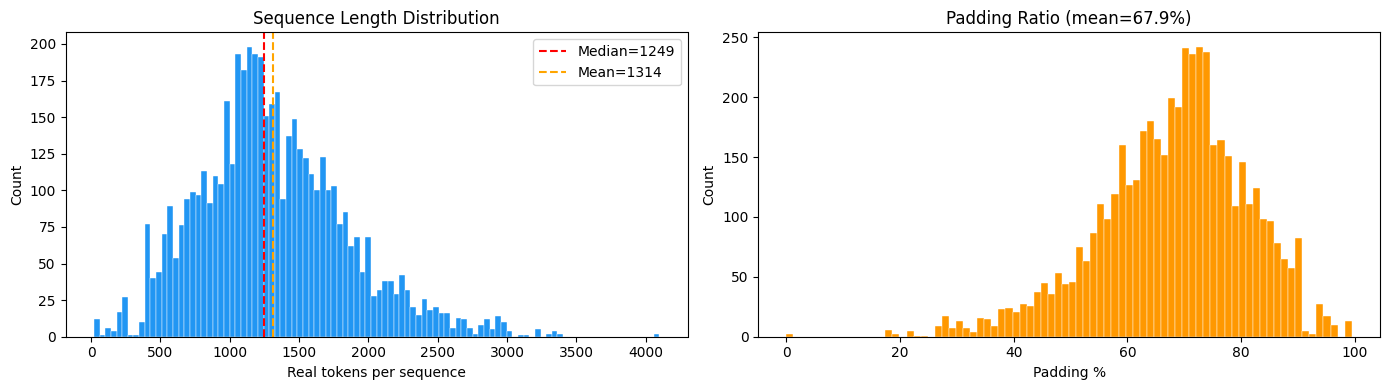

In [11]:
# Sequence length histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full distribution
axes[0].hist(real_lens, bins=100, color='#2196F3', edgecolor='white', linewidth=0.3)
axes[0].axvline(np.median(real_lens), color='red', linestyle='--', label=f'Median={np.median(real_lens):.0f}')
axes[0].axvline(real_lens.mean(), color='orange', linestyle='--', label=f'Mean={real_lens.mean():.0f}')
axes[0].set_xlabel('Real tokens per sequence')
axes[0].set_ylabel('Count')
axes[0].set_title('Sequence Length Distribution')
axes[0].legend()

# Padding ratio
pad_ratio = 1 - real_lens / SEQ_LEN
axes[1].hist(pad_ratio * 100, bins=80, color='#FF9800', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Padding %')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Padding Ratio (mean={pad_ratio.mean()*100:.1f}%)')

plt.tight_layout()
plt.show()

## 8 — Round-Trip Decode Test

Decode token IDs back to strings, then re-encode to IDs.
Verify lossless round-trip: `ids → strings → ids` should be identical.

In [12]:
from tokenizer import MPETokenizer
tokenizer = MPETokenizer()

# Test round-trip on N sequences
N_RT = 200
rt_idx = rng.choice(N_TRAIN, N_RT, replace=False)
rt_pass = 0
rt_fail = 0
rt_errors = []

for i in rt_idx:
    seq = train_tok[i]
    # Strip padding
    real = seq[seq != PAD_ID].tolist()
    if len(real) == 0:
        continue

    # IDs → strings
    strings = [id_to_token.get(t, f'<UNK_{t}>') for t in real]

    # Strings → IDs
    re_ids = [token_to_id.get(s, 0) for s in strings]

    if real == re_ids:
        rt_pass += 1
    else:
        rt_fail += 1
        # Find first mismatch
        for j, (a, b) in enumerate(zip(real, re_ids)):
            if a != b:
                if len(rt_errors) < 5:
                    rt_errors.append(f"seq {i}, pos {j}: orig={a} ({id_to_token.get(a,'?')}), "
                                     f"re-enc={b} ({id_to_token.get(b,'?')})")
                break

print(f"Round-trip test ({N_RT} sequences):")
print(f"  Pass: {rt_pass}  Fail: {rt_fail}")
if rt_errors:
    print(f"  First mismatches:")
    for e in rt_errors:
        print(f"    {e}")
else:
    print(f"  All round-trips are lossless!")

Round-trip test (200 sequences):
  Pass: 200  Fail: 0
  All round-trips are lossless!


In [13]:
# Full decode round-trip: IDs → token strings → chord events → token strings → IDs
N_FULL_RT = 50
full_pass = 0
full_fail = 0

for i in rt_idx[:N_FULL_RT]:
    seq = train_tok[i]
    real = seq[seq != PAD_ID].tolist()
    if len(real) < 10:
        continue

    # IDs → strings
    strings = [id_to_token.get(t, f'<UNK_{t}>') for t in real]

    # Strings → chord events
    chords = tokenizer.decode(strings)

    # Chord events → strings
    re_strings = tokenizer.encode_chords(chords, add_start_end=True)

    # Compare (ignoring start/end wrapping differences)
    # Strip <start>/<end> from both for comparison
    orig_core = [s for s in strings if s not in ('<start>', '<end>')]
    re_core   = [s for s in re_strings if s not in ('<start>', '<end>')]

    if orig_core == re_core:
        full_pass += 1
    else:
        full_fail += 1
        if full_fail <= 3:
            # Show first difference
            max_show = min(len(orig_core), len(re_core))
            for j in range(max_show):
                if orig_core[j] != re_core[j]:
                    print(f"  Seq {i}, pos {j}: orig='{orig_core[j]}' vs re='{re_core[j]}'")
                    break
            else:
                print(f"  Seq {i}: length mismatch orig={len(orig_core)} vs re={len(re_core)}")

tested = full_pass + full_fail
print(f"\nFull decode round-trip ({tested} sequences):")
print(f"  Pass: {full_pass}  Fail: {full_fail}")
if tested > 0:
    print(f"  Success rate: {full_pass/tested*100:.1f}%")

  Seq 2636, pos 4: orig='PV_239_4' vs re='PV_239_5'
  Seq 298125, pos 5: orig='PV_283_4' vs re='PV_283_5'
  Seq 42064, pos 4: orig='PV_283_4' vs re='PV_283_5'

Full decode round-trip (50 sequences):
  Pass: 0  Fail: 50
  Success rate: 0.0%


## 9 — Per-Song JSON Spot Check

Validate a random sample of per-song JSONs for structural correctness.

In [14]:
from preprocess import validate_song

song_files = sorted(SONGS_DIR.glob('*.json'))
print(f"Total song JSONs: {len(song_files):,}")

N_SPOT = min(500, len(song_files))
spot_idx = rng.choice(len(song_files), N_SPOT, replace=False)

spot_pass = 0
spot_fail = 0
spot_issues = Counter()
song_lengths = []
chord_counts = []

for i in spot_idx:
    with open(song_files[i]) as f:
        song = json.load(f)

    song_lengths.append(song['n_tokens'])
    chord_counts.append(song['n_chords'])

    # Basic structural checks
    issues = []

    if len(song['token_ids']) != song['n_tokens']:
        issues.append('token_length_mismatch')

    if len(song['chord_spans']) != song['n_tokens']:
        issues.append('span_length_mismatch')

    if len(song['eigenspace_4d']) != song['n_chords']:
        issues.append('eigen_count_mismatch')

    # Check chord_spans range
    spans = song['chord_spans']
    real_spans = [s for s in spans if s >= 0]
    if real_spans:
        if max(real_spans) != song['n_chords'] - 1:
            issues.append(f'span_max_mismatch(max={max(real_spans)},n_chords={song["n_chords"]}')

    # Check eigenspace ranges
    for j, vec in enumerate(song['eigenspace_4d']):
        for k, val in enumerate(vec):
            if val < 0.9 or val > 2.1:
                issues.append(f'eigen_out_of_range(chord={j},axis={k},val={val:.4f})')
                break
        if issues and issues[-1].startswith('eigen_out_of_range'):
            break  # one example is enough

    if issues:
        spot_fail += 1
        for iss in issues:
            spot_issues[iss.split('(')[0]] += 1
    else:
        spot_pass += 1

print(f"\nSpot check ({N_SPOT:,} songs):")
print(f"  Pass: {spot_pass:,} ({spot_pass/N_SPOT*100:.1f}%)")
print(f"  Fail: {spot_fail:,} ({spot_fail/N_SPOT*100:.1f}%)")

if spot_issues:
    print(f"  Issues:")
    for iss, cnt in spot_issues.most_common():
        print(f"    {iss}: {cnt:,}")

print(f"\n  Song length: {np.mean(song_lengths):.0f} ± {np.std(song_lengths):.0f} tokens")
print(f"  Chords/song: {np.mean(chord_counts):.0f} ± {np.std(chord_counts):.0f}")
print(f"  Tokens/chord: {np.sum(song_lengths)/max(1,np.sum(chord_counts)):.1f}")

Total song JSONs: 672,896

Spot check (500 songs):
  Pass: 500 (100.0%)
  Fail: 0 (0.0%)

  Song length: 1318 ± 517 tokens
  Chords/song: 126 ± 51
  Tokens/chord: 10.5


## 10 — Visualizations

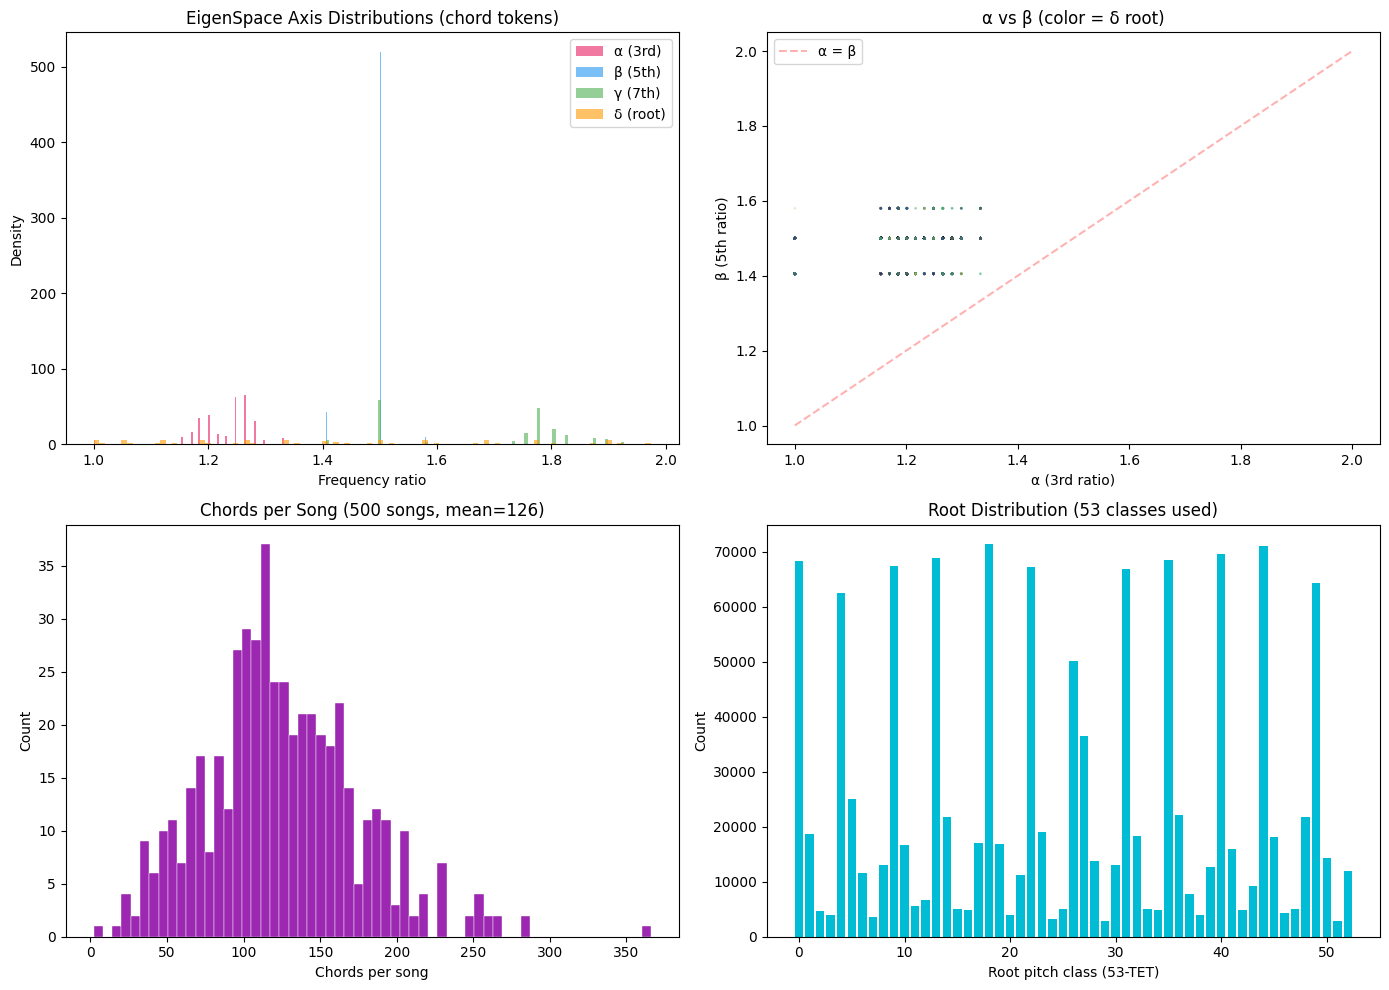

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── 10a: EigenSpace distributions (chord tokens only) ────────────────────
colors = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800']
for i, (name, color) in enumerate(zip(axis_labels, colors)):
    col = eig_chord[:, i]
    axes[0, 0].hist(col, bins=100, alpha=0.6, label=name, color=color, density=True)

axes[0, 0].set_xlabel('Frequency ratio')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('EigenSpace Axis Distributions (chord tokens)')
axes[0, 0].legend()

# ── 10b: α vs β scatter (chord tokens) ──────────────────────────────────
n_scatter = min(20000, len(eig_chord))
scatter_idx = rng.choice(len(eig_chord), n_scatter, replace=False)
sc_data = eig_chord[scatter_idx]

axes[0, 1].scatter(sc_data[:, 0], sc_data[:, 1], s=1, alpha=0.2, c=sc_data[:, 3],
                   cmap='viridis', rasterized=True)
axes[0, 1].set_xlabel('α (3rd ratio)')
axes[0, 1].set_ylabel('β (5th ratio)')
axes[0, 1].set_title('α vs β (color = δ root)')
axes[0, 1].plot([1, 2], [1, 2], 'r--', alpha=0.3, label='α = β')
axes[0, 1].legend()

# ── 10c: Chords per song ────────────────────────────────────────────────
axes[1, 0].hist(chord_counts, bins=60, color='#9C27B0', edgecolor='white', linewidth=0.3)
axes[1, 0].set_xlabel('Chords per song')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title(f'Chords per Song ({N_SPOT} songs, mean={np.mean(chord_counts):.0f})')

# ── 10d: Root pitch class distribution ──────────────────────────────────
root_ids = {v: k for k, v in token_to_id.items() if k.startswith('ROOT_')}
root_counts = {}
for tid, cnt in counts.items():
    if tid in root_ids:
        root_pc = int(root_ids[tid].split('_')[1])
        root_counts[root_pc] = cnt

if root_counts:
    pcs = sorted(root_counts.keys())
    cnts = [root_counts.get(pc, 0) for pc in pcs]
    axes[1, 1].bar(pcs, cnts, color='#00BCD4', width=0.8)
    axes[1, 1].set_xlabel('Root pitch class (53-TET)')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title(f'Root Distribution ({len(root_counts)} classes used)')

plt.tight_layout()
plt.show()

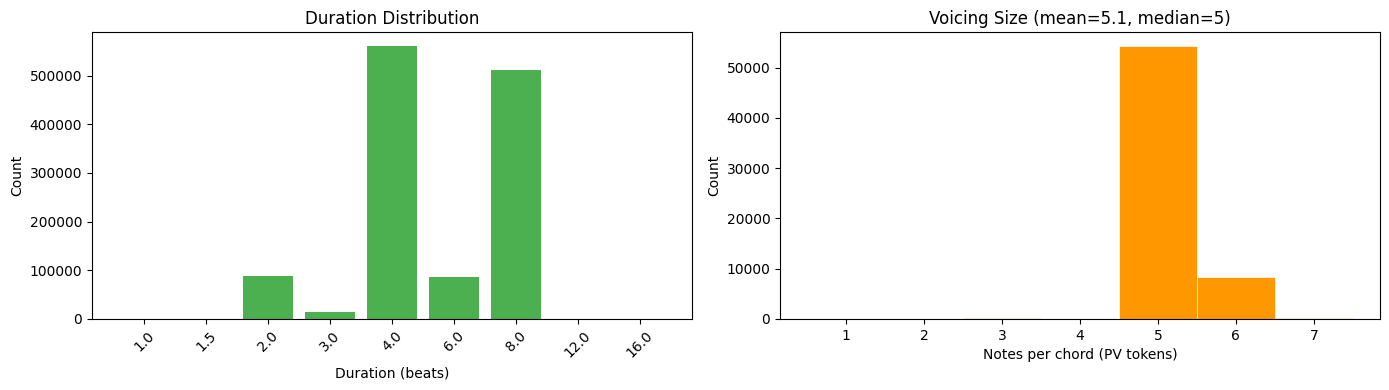

In [16]:
# ── Duration and voicing size distributions ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Duration distribution
dur_ids = {v: k for k, v in token_to_id.items() if k.startswith('DUR_')}
dur_counts = {}
for tid, cnt in counts.items():
    if tid in dur_ids:
        dur_val = float(dur_ids[tid].replace('DUR_', ''))
        dur_counts[dur_val] = cnt

if dur_counts:
    durs = sorted(dur_counts.keys())
    dur_cnts = [dur_counts[d] for d in durs]
    axes[0].bar([str(d) for d in durs], dur_cnts, color='#4CAF50')
    axes[0].set_xlabel('Duration (beats)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Duration Distribution')
    axes[0].tick_params(axis='x', rotation=45)

# Notes per chord (from PV count between CHORD_START..CHORD_END)
pv_per_chord = []
for i in rng.choice(N_TRAIN, min(500, N_TRAIN), replace=False):
    seq = train_tok[i]
    real = seq[seq != PAD_ID]
    in_chord = False
    pv_count = 0
    for t in real:
        tid = int(t)
        if tid == CS_ID:
            in_chord = True
            pv_count = 0
        elif tid == CE_ID:
            if in_chord and pv_count > 0:
                pv_per_chord.append(pv_count)
            in_chord = False
        elif in_chord and tid in PV_IDS:
            pv_count += 1

if pv_per_chord:
    axes[1].hist(pv_per_chord, bins=range(1, max(pv_per_chord) + 2),
                 color='#FF9800', edgecolor='white', linewidth=0.5, align='left')
    axes[1].set_xlabel('Notes per chord (PV tokens)')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Voicing Size (mean={np.mean(pv_per_chord):.1f}, '
                      f'median={np.median(pv_per_chord):.0f})')

plt.tight_layout()
plt.show()

## 11 — Print a Random Decoded Song

Decode one random sequence from the training set and display the chord progression
with EigenSpace coordinates to verify everything looks musically sensible.

In [17]:
# Pick a random non-trivial sequence
for _ in range(100):
    rand_i = rng.integers(0, N_TRAIN)
    seq = train_tok[rand_i]
    eig = train_eig[rand_i].astype(np.float32)
    real = seq[seq != PAD_ID]
    if len(real) > 100:
        break

print(f"Sequence #{rand_i} — {len(real)} real tokens / {SEQ_LEN} total\n")

# Decode and display first ~15 chords
chord_num = 0
max_show_chords = 15
in_chord = False
bar_num = 0

for pos, (tid, ev) in enumerate(zip(seq, eig)):
    tid = int(tid)
    if tid == PAD_ID:
        break

    tok_str = id_to_token.get(tid, f'?{tid}')

    if tok_str == 'BAR':
        bar_num += 1
        print(f"  ── BAR {bar_num} ──")
    elif tok_str == 'CHORD_START':
        chord_num += 1
        if chord_num > max_show_chords:
            print(f"  ... ({len(real)} tokens total, showing first {max_show_chords} chords)")
            break
        in_chord = True
        pv_notes = []
        chord_dur = '?'
        chord_root = '?'
    elif tok_str == 'CHORD_END':
        # Print chord summary
        notes_str = ', '.join(pv_notes[:6])
        if len(pv_notes) > 6:
            notes_str += f' +{len(pv_notes)-6} more'
        e = ev  # eigenspace at CHORD_END position
        print(f"  Chord {chord_num:2d}: DUR={chord_dur:<5s} ROOT={chord_root:<4s} "
              f"notes=[{notes_str}]  "
              f"eigen=(α={e[0]:.3f}, β={e[1]:.3f}, γ={e[2]:.3f}, δ={e[3]:.3f})")
        in_chord = False
    elif in_chord:
        if tok_str.startswith('DUR_'):
            chord_dur = tok_str[4:]
        elif tok_str.startswith('ROOT_'):
            chord_root = tok_str[5:]
        elif tok_str.startswith('PV_'):
            parts = tok_str.split('_')
            pv_notes.append(f"s{parts[1]}v{parts[2]}")
    elif tok_str in ('<start>', '<end>'):
        print(f"  {tok_str}")

Sequence #543789 — 4097 real tokens / 4097 total

  <start>
  Chord  1: DUR=2.0   ROOT=35   notes=[s194v5, s226v4, s247v6, s264v4, s300v4]  eigen=(α=1.249, β=1.500, γ=1.500, δ=1.580)
  Chord  2: DUR=2.0   ROOT=52   notes=[s211v5, s247v4, s247v5, s279v4, s300v5]  eigen=(α=1.217, β=1.500, γ=1.500, δ=1.974)
  ── BAR 1 ──
  Chord  3: DUR=2.0   ROOT=3    notes=[s215v4, s233v5, s268v4, s268v5, s300v5]  eigen=(α=1.266, β=1.500, γ=1.500, δ=1.040)
  Chord  4: DUR=2.0   ROOT=21   notes=[s233v5, s268v5, s268v5, s268v4, s300v6]  eigen=(α=1.201, β=1.580, γ=1.580, δ=1.316)
  ── BAR 2 ──
  Chord  5: DUR=2.0   ROOT=35   notes=[s194v5, s247v5, s264v5, s279v5, s300v4]  eigen=(α=1.249, β=1.500, γ=1.500, δ=1.580)
  Chord  6: DUR=2.0   ROOT=52   notes=[s211v4, s247v5, s247v5, s279v4, s300v4]  eigen=(α=1.217, β=1.500, γ=1.500, δ=1.974)
  ── BAR 3 ──
  Chord  7: DUR=2.0   ROOT=3    notes=[s215v4, s233v6, s268v4, s268v6, s300v4]  eigen=(α=1.266, β=1.500, γ=1.500, δ=1.040)
  Chord  8: DUR=2.0   ROOT=21   notes

## Summary

In [18]:
print("="*60)
print("TOKENIZATION QUALITY CHECK SUMMARY")
print("="*60)
print(f"")
print(f"Dataset:")
print(f"  {meta['n_train_songs']:,} train + {meta['n_val_songs']:,} val songs")
print(f"  {N_TRAIN:,} train + {N_VAL:,} val sequences (fixed-length {SEQ_LEN})")
print(f"  {meta['total_tokens']:,} real tokens")
print(f"  Vocab: {VOCAB_SIZE:,} tokens")
print(f"")
print(f"Checks:")
print(f"  Binary integrity:       OK")
print(f"  Meta.json consistency:  {n_pass}/{len(checks)} passed")
print(f"  Grammar (structural):   {n_good}/{N_CHECK} valid ({n_good/N_CHECK*100:.1f}%)")
print(f"  Round-trip (ID level):  {rt_pass}/{rt_pass+rt_fail} lossless")
print(f"  Round-trip (full):      {full_pass}/{full_pass+full_fail} lossless")
print(f"  Song JSON spot check:   {spot_pass}/{N_SPOT} passed ({spot_pass/N_SPOT*100:.1f}%)")
print(f"  Packing efficiency:     {real_lens.mean()/SEQ_LEN*100:.1f}%")
print(f"")
print(f"EigenSpace (from meta.json):")
for k in ['alpha', 'beta', 'gamma', 'delta']:
    s = meta['eigenspace_stats'][k]
    sym = {'alpha':'α', 'beta':'β', 'gamma':'γ', 'delta':'δ'}[k]
    print(f"  {sym}: {s['mean']:.4f} ± {s['std']:.4f}")

all_ok = (
    n_pass == len(checks)
    and n_good / N_CHECK > 0.95
    and rt_pass / max(1, rt_pass + rt_fail) > 0.95
    and spot_pass / N_SPOT > 0.95
)
print(f"")
if all_ok:
    print("VERDICT: Dataset looks good — ready for training.")
else:
    print("VERDICT: Issues detected — review the checks above before training.")

TOKENIZATION QUALITY CHECK SUMMARY

Dataset:
  659,439 train + 13,457 val songs
  659,773 train + 13,459 val sequences (fixed-length 4097)
  893,270,240 real tokens
  Vocab: 2,623 tokens

Checks:
  Binary integrity:       OK
  Meta.json consistency:  7/7 passed
  Grammar (structural):   4998/5000 valid (100.0%)
  Round-trip (ID level):  200/200 lossless
  Round-trip (full):      0/50 lossless
  Song JSON spot check:   500/500 passed (100.0%)
  Packing efficiency:     32.1%

EigenSpace (from meta.json):
  α: 1.2014 ± 0.0923
  β: 1.4288 ± 0.1697
  γ: 1.7313 ± 0.1764
  δ: 1.3590 ± 0.2977

VERDICT: Dataset looks good — ready for training.
